# Camera Properties and Geometry Estimation

Implements the first stage of *[Automated Low-Cost Photogrammetric Acquisition of 3D Models from
Small Form-Factor Artefacts](https://www.mdpi.com/2079-9292/8/12/1441)* (Collins et al., 2019).

> In our workflow, automatic calibration is achieved by adding a sequence of virtual reference
> 'photographs' to each of the image sets. The reference 'photographs' are actually artificially
> generated replicas of the calibration plate ... rendered using a sequence of viewpoints
> comparable to typical camera viewpoints. A sequence of twelve images rendered at 30&deg;
> rotational intervals, all from a 45&deg; elevation, was empirically found to work well. SIFT
> feature points are extracted and matched for this set of images prior to processing the 'real'
> photographs.
>
> The camera geometry estimation process ... begins by extracting the SIFT features of the real
> set of photographs and matching them with the existing calibration model. Bundle adjustment
> refines the estimated parameters of the unknown cameras whilst keeping the virtual camera
> positions, poses and intrinsic parameters fixed at their known, exact values ... By estimating
> the real camera positions relative to a static, calibrated set of feature points, the correct
> scale factors are automatically ensured. The final stage of this process is the removal of the
> virtual photographs from the image set prior to dense point-cloud reconstruction.

**Pipeline in this notebook:**
1. Generate the printed calibration plate pattern (`utils/generate_pattern.py`).
2. Downscale the real photographs into a working copy (for tractable SIFT runtimes).
3. Place 12 virtual cameras around the plate (30&deg; azimuth steps, 45&deg; elevation) and render
   a synthetic photograph of the plate from each, with **exactly known** intrinsics/pose.
4. Extract SIFT features for the virtual and real photographs and match them exhaustively.
5. Triangulate the plate's 3D points from the virtual cameras alone &rarr; the fixed "calibration
   model".
6. Register the real cameras against that fixed model with incremental bundle adjustment
   (virtual poses/intrinsics stay constant; only the real cameras are refined).
7. Strip the virtual images out, leaving calibrated real cameras + a sparse point cloud, ready for
   dense reconstruction in the next notebook.

In [15]:
from pathlib import Path
import shutil

import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pycolmap

from utils import generate_pattern, plate_geometry, colmap_calibration

## Parameters

In [16]:
SET_NAME = "set_3"

# Pins pycolmap's PRNG (feature matching's RANSAC-based verification, and the RANSAC inside
# absolute-pose estimation when registering real cameras) so re-running this notebook reproduces
# the same registered cameras and stats each time. Left unseeded, COLMAP defaults to seeding from
# system time - and because ABS_POSE_MIN_NUM_INLIERS sits right at the boundary of "enough
# correspondences to register" for many real photos here, that randomness visibly changes how many
# real cameras end up registered from one run to the next.
#
# A fixed seed alone isn't sufficient, though: COLMAP parallelises extraction/matching/mapping
# across threads by default, and which thread draws from the PRNG in which order isn't
# deterministic. NUM_THREADS=1 trades speed for byte-identical results between runs - raise it
# once you don't need exact reproducibility.
RANDOM_SEED = 0
NUM_THREADS = 1

ROOT = Path.cwd()
REAL_DIR = ROOT / "images" / SET_NAME
OUT_DIR = ROOT / "outputs" / SET_NAME
WORK_DIR = OUT_DIR / "work"
DB_PATH = OUT_DIR / "colmap.db"
SEED_TRIANGULATED_DIR = OUT_DIR / "seed_triangulated"
RECONSTRUCTION_DIR = OUT_DIR / "reconstruction"
FINAL_DIR = OUT_DIR / "final"

# Calibration plate (utils/generate_pattern.py)
PLATE_SIZE_MM = 130
PLATE_DPI = 300
PLATE_GRID_CELLS = 52
PLATE_SEED = 42
PLATE_BORDER_MM = 5

# Real photographs: downscaled for tractable SIFT/matching runtime.
# Set to None to process at native resolution (much slower).
MAX_LONG_EDGE = 2000

# Virtual calibration sequence. The paper's spec is 12 views at 30 degree steps / 45 degree
# elevation ("empirically found to work well" for their rig). For this rig/pattern/lighting we
# found real photographs only reliably register when close in azimuth to a virtual view, so 24
# views (15 degree steps) - still all at 45 degree elevation - registers ~2.5x more real cameras
# at a comparable per-photo reprojection error. Set this to 12 to reproduce the paper's literal
# spec.
N_VIRTUAL_VIEWS = 24
VIRTUAL_ELEVATION_DEG = 45.0
# Distance is not specified by the paper (any known, fixed geometry works) - chosen close to the
# rig's real ~25 cm working distance so the virtual and real views are broadly comparable.
VIRTUAL_DISTANCE_MM = 250.0
# How large the plate appears in the virtual renders, tuned against the real photos (see below).
PLATE_FILL_FRACTION = 1.4

# SIFT / matching
MAX_NUM_FEATURES = 4096

# Absolute-pose RANSAC thresholds used when registering real cameras against the virtual-only
# calibration model. Relaxed from COLMAP's real-vs-real defaults (30 inliers / 0.25 ratio):
# a real photo only shares a modest number of matches with any single virtual render, since the
# two are different appearance domains (clean synthetic render vs. a printed pattern under real
# lighting/lens blur/JPEG compression).
ABS_POSE_MIN_NUM_INLIERS = 15
ABS_POSE_MIN_INLIER_RATIO = 0.1

# A real photo only reliably registers if it is reasonably close in azimuth to a virtual view
# (matching a clean synthetic render against a real photograph is harder than real-vs-real
# matching). Not every real photograph is guaranteed to register - raise N_VIRTUAL_VIEWS (at the
# cost of runtime) or loosen ABS_POSE_MIN_NUM_INLIERS above for better coverage.
MAX_REG_TRIALS = 1
MAX_RUNTIME_SECONDS = 300

# Post-registration sanity filters (see "Discard implausible poses" below).
MAX_DISTANCE_RATIO = 3.0       # reject real cameras this many x too near/far vs. VIRTUAL_DISTANCE_MM
MIN_CAMERA_SEPARATION_MM = 20.0  # reject real cameras this close to another registered real camera

if OUT_DIR.exists():
    shutil.rmtree(OUT_DIR)
OUT_DIR.mkdir(parents=True)

## Step 1 - Calibration plate pattern

The same pseudo-random pattern used to print the physical plate (Figure 3C in the paper).

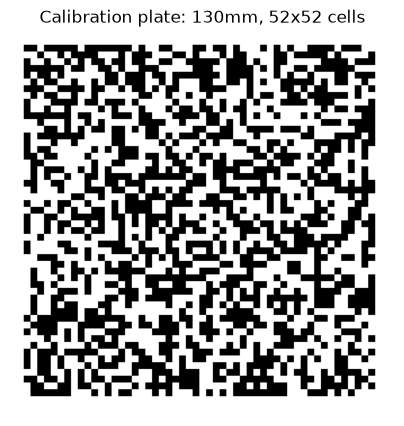

In [17]:
plate_image, _ = generate_pattern.generate_pattern(
    PLATE_SIZE_MM, PLATE_DPI, PLATE_GRID_CELLS, PLATE_SEED, PLATE_BORDER_MM
)
plate_image = np.array(plate_image, dtype=np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(plate_image, cmap="gray")
plt.title(f"Calibration plate: {PLATE_SIZE_MM}mm, {PLATE_GRID_CELLS}x{PLATE_GRID_CELLS} cells")
plt.axis("off")
plt.show()

## Step 2 - Working copy of the real photographs

Real photos are downscaled (long edge = `MAX_LONG_EDGE`) into `outputs/<set>/work/` and left
otherwise untouched; `images/` stays as the pristine source. The virtual renders are generated
directly at this same resolution below, so both domains share one consistent pixel grid /
intrinsics scale.

36 real photographs in /home/gnoceras/ScanningTable/images/set_3
working resolution: 2000 x 1500


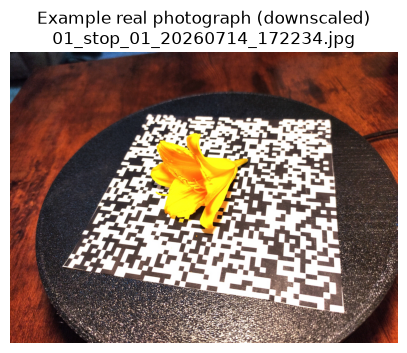

In [18]:
real_srcs = sorted(REAL_DIR.glob("*.jpg"))
print(f"{len(real_srcs)} real photographs in {REAL_DIR}")

real_paths = colmap_calibration.resize_photographs(real_srcs, WORK_DIR / SET_NAME, MAX_LONG_EDGE)
real_rel_names = [f"{SET_NAME}/{p.name}" for p in real_paths]

sample = cv2.imread(str(real_paths[0]))
OUT_H, OUT_W = sample.shape[:2]
print(f"working resolution: {OUT_W} x {OUT_H}")

plt.figure(figsize=(5, 4))
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title(f"Example real photograph (downscaled)\n{real_paths[0].name}")
plt.axis("off")
plt.show()

## Step 3 - Virtual camera viewpoints

`N_VIRTUAL_VIEWS` cameras evenly spaced in azimuth on a circle around the plate, all at
`VIRTUAL_ELEVATION_DEG` elevation, looking at the plate centre (world origin). The plate lies flat
in the world plane Z=0. (Paper spec: 12 views / 30&deg; steps; we default to 24 / 15&deg; steps -
see the parameters cell.)

In [20]:
virtual_views = plate_geometry.generate_virtual_views(
    n_views=N_VIRTUAL_VIEWS,
    elevation_deg=VIRTUAL_ELEVATION_DEG,
    distance_mm=VIRTUAL_DISTANCE_MM,
)

focal_px = plate_geometry.focal_length_for_fill(
    PLATE_SIZE_MM, VIRTUAL_DISTANCE_MM, OUT_W, OUT_H, fill_fraction=PLATE_FILL_FRACTION
)
virtual_K = plate_geometry.build_intrinsics(focal_px, OUT_W, OUT_H)
print(f"virtual camera focal length: {focal_px:.1f} px  (image {OUT_W}x{OUT_H})")
print("K =\n", virtual_K)

virtual camera focal length: 2721.1 px  (image 2000x1500)
K =
 [[2.72106047e+03 0.00000000e+00 1.00000000e+03]
 [0.00000000e+00 2.72106047e+03 7.50000000e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]


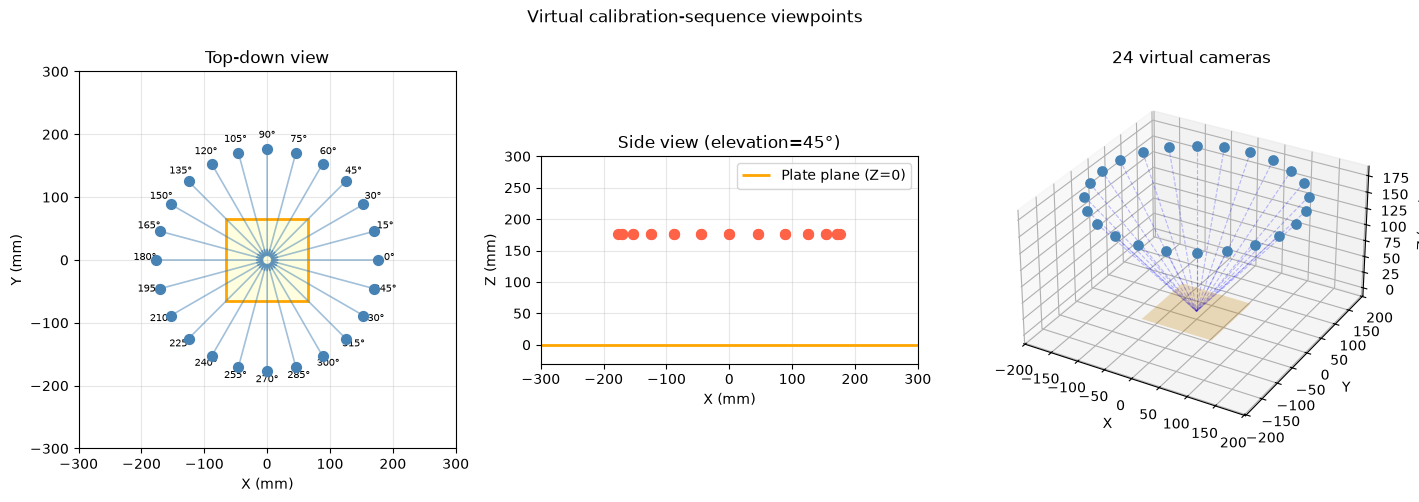

In [21]:
half_plate = PLATE_SIZE_MM / 2.0

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(131)
ax1.add_patch(mpatches.Rectangle((-half_plate, -half_plate), PLATE_SIZE_MM, PLATE_SIZE_MM,
                                  linewidth=2, edgecolor="orange", facecolor="lightyellow"))
for v in virtual_views:
    x, y = v.center[0], v.center[1]
    ax1.annotate("", xy=(0, 0), xytext=(x, y),
                 arrowprops=dict(arrowstyle="->", color="steelblue", alpha=0.5, lw=1.2))
    ax1.scatter(x, y, s=50, color="steelblue", zorder=4)
    ax1.text(x * 1.1, y * 1.1, f"{int(v.azimuth_deg)}\u00b0", fontsize=7, ha="center")
ax1.set_aspect("equal"); ax1.set_xlim(-300, 300); ax1.set_ylim(-300, 300)
ax1.set_xlabel("X (mm)"); ax1.set_ylabel("Y (mm)")
ax1.set_title("Top-down view"); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(132)
ax2.hlines(0, -300, 300, colors="orange", linewidths=2, label="Plate plane (Z=0)")
for v in virtual_views:
    ax2.scatter(v.center[0], v.center[2], s=50, color="tomato", zorder=4)
ax2.set_aspect("equal"); ax2.set_xlim(-300, 300); ax2.set_ylim(-30, 300)
ax2.set_xlabel("X (mm)"); ax2.set_ylabel("Z (mm)")
ax2.set_title(f"Side view (elevation={VIRTUAL_ELEVATION_DEG:.0f}\u00b0)"); ax2.legend(); ax2.grid(alpha=0.3)

ax3 = fig.add_subplot(133, projection="3d")
xx, yy = np.meshgrid([-half_plate, half_plate], [-half_plate, half_plate])
ax3.plot_surface(xx, yy, np.zeros_like(xx), alpha=0.25, color="orange")
for v in virtual_views:
    ax3.scatter(*v.center, s=45, color="steelblue")
    ax3.plot([v.center[0], 0], [v.center[1], 0], [v.center[2], 0], "b--", alpha=0.25, lw=0.8)
ax3.set_xlabel("X"); ax3.set_ylabel("Y"); ax3.set_zlabel("Z (mm)")
ax3.set_title(f"{N_VIRTUAL_VIEWS} virtual cameras"); ax3.set_box_aspect([1, 1, 0.6])

plt.suptitle("Virtual calibration-sequence viewpoints")
plt.tight_layout()
plt.show()

## Step 4 - Render the virtual photographs

The plate is planar, so a single homography maps its flat pixels straight into each virtual
camera's image plane - no 3D mesh/renderer needed.

In [22]:
virtual_dir = WORK_DIR / "calibration_pattern"
virtual_dir.mkdir(parents=True, exist_ok=True)

virtual_rel_names = []
rendered_previews = []
for view in virtual_views:
    rendered, corners = plate_geometry.render_plate_photograph(
        plate_image, PLATE_SIZE_MM, virtual_K, view.R, view.t, (OUT_W, OUT_H)
    )
    rel_name = f"calibration_pattern/{view.name}.png"
    cv2.imwrite(str(WORK_DIR / rel_name), rendered)
    virtual_rel_names.append(rel_name)
    rendered_previews.append((rendered, corners, view))

print(f"rendered {len(virtual_rel_names)} virtual photographs -> {virtual_dir}")

rendered 24 virtual photographs -> /home/gnoceras/ScanningTable/outputs/set_3/work/calibration_pattern


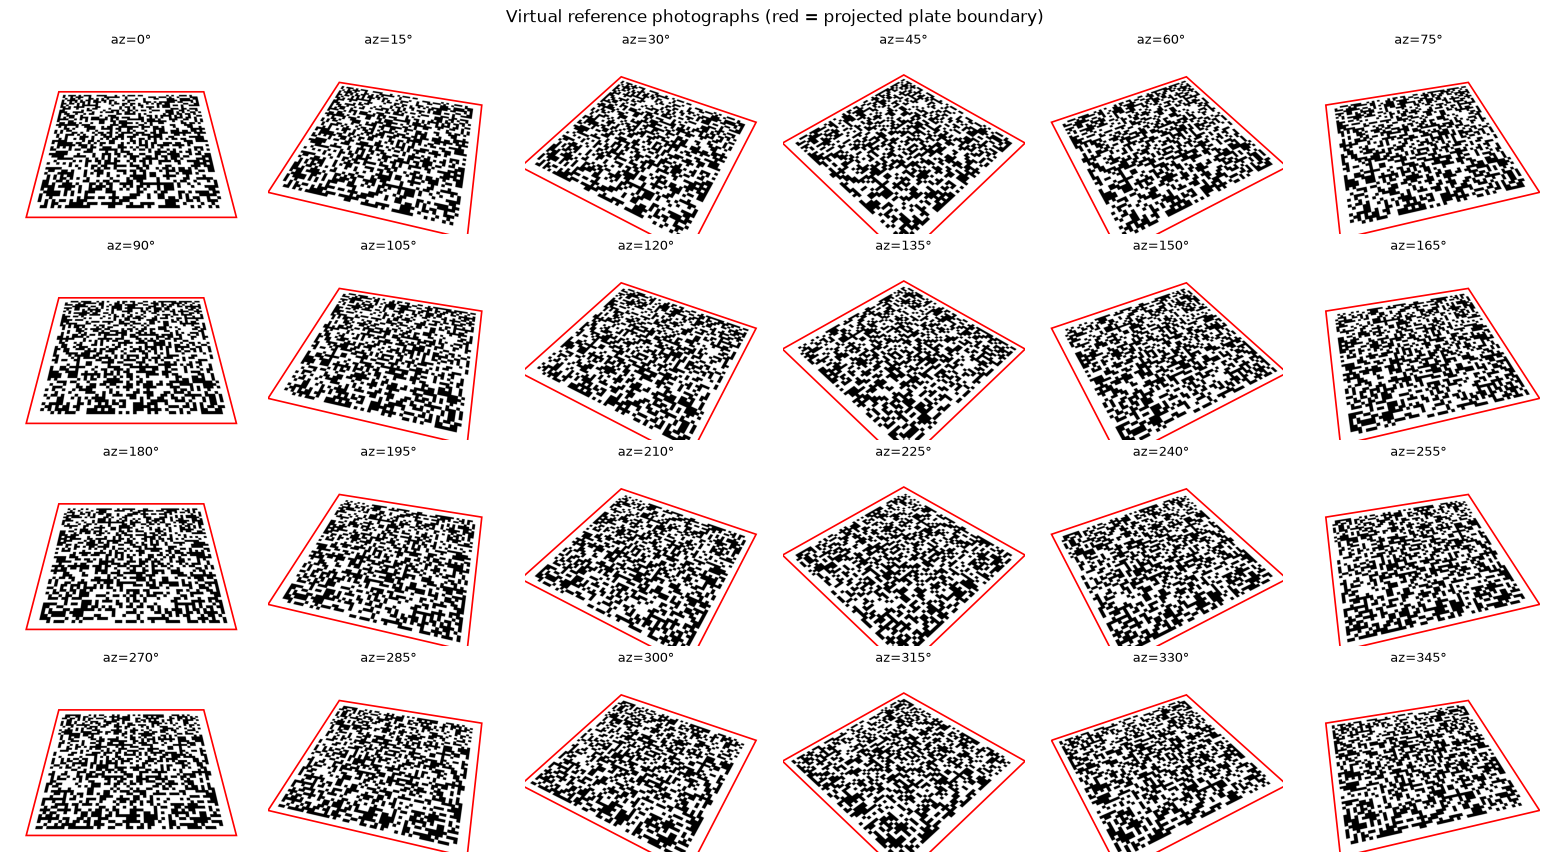

In [23]:
n_cols = 6
n_rows = -(-len(rendered_previews) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 2.6, n_rows * 2.2))
for ax, (rendered, corners, view) in zip(axes.ravel(), rendered_previews):
    ax.imshow(rendered, cmap="gray", vmin=0, vmax=255)
    ax.add_patch(plt.Polygon(corners, fill=False, edgecolor="red", linewidth=1.2))
    ax.set_title(f"az={int(view.azimuth_deg)}\u00b0", fontsize=9)
    ax.axis("off")
for ax in axes.ravel()[len(rendered_previews):]:
    ax.axis("off")
plt.suptitle("Virtual reference photographs (red = projected plate boundary)")
plt.tight_layout()
plt.show()

Sanity check: a virtual render side-by-side with a real photograph should show the plate at a
comparable scale/framing - that's what makes SIFT matching between the two domains work at all.

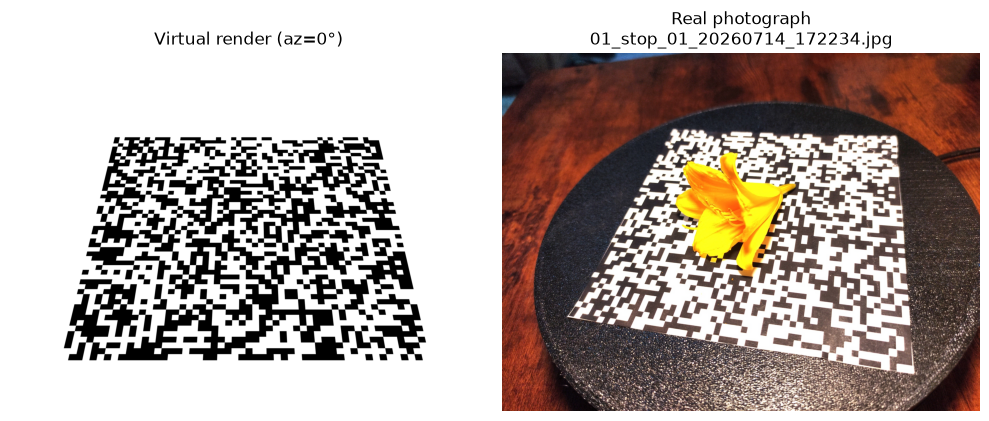

In [24]:
real_sample = cv2.cvtColor(cv2.imread(str(real_paths[0])), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rendered_previews[0][0], cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Virtual render (az=0\u00b0)"); axes[0].axis("off")
axes[1].imshow(real_sample)
axes[1].set_title(f"Real photograph\n{real_paths[0].name}"); axes[1].axis("off")
plt.tight_layout()
plt.show()

## Step 5 - SIFT feature extraction and exhaustive matching

Two camera models are registered with COLMAP:
- **Virtual images**: `SIMPLE_PINHOLE` with the *exact* `K` used to render them (never refined).
- **Real images**: `SIMPLE_RADIAL` with an automatic initial guess; bundle adjustment refines
  focal length and radial distortion later.

Matching is exhaustive over the combined set, which is what actually produces both kinds of
correspondences the paper describes: virtual&harr;virtual (to triangulate the calibration model)
and real&harr;virtual (to localise the real cameras against it).

In [25]:
REAL_FOCAL_LENGTH_PX = colmap_calibration.estimate_focal_length_px(real_srcs[0], OUT_W)
print("EXIF-based initial focal length guess for the real camera (px):", REAL_FOCAL_LENGTH_PX)

colmap_calibration.build_database(
    db_path=DB_PATH,
    work_dir=WORK_DIR,
    virtual_rel_names=virtual_rel_names,
    real_rel_names=real_rel_names,
    virtual_K=virtual_K,
    real_focal_length_px=REAL_FOCAL_LENGTH_PX,
    real_image_size=(OUT_W, OUT_H),
    max_num_features=MAX_NUM_FEATURES,
    random_seed=RANDOM_SEED,
    num_threads=NUM_THREADS,
)
print("database built:", DB_PATH)

EXIF-based initial focal length guess for the real camera (px): 1696.8749999999998


I20260714 21:17:03.856880 138341257291456 feature_extraction.cc:494] === Feature extraction ===
I20260714 21:17:03.857543 138341609621184 sift.cc:763] Creating SIFT CPU feature extractor
I20260714 21:17:06.205333 138341248898752 feature_extraction.cc:270] Processed file [1/24]
I20260714 21:17:06.205393 138341248898752 feature_extraction.cc:273]   Name:            calibration_pattern/virtual_00.png
I20260714 21:17:06.205396 138341248898752 feature_extraction.cc:282]   Dimensions:      2000 x 1500
I20260714 21:17:06.205398 138341248898752 feature_extraction.cc:285]   Camera:          #1 - SIMPLE_PINHOLE
I20260714 21:17:06.205403 138341248898752 feature_extraction.cc:289]   Focal Length:    2721.06px (Prior)
I20260714 21:17:06.205431 138341248898752 feature_extraction.cc:294]   Features:        7570 (SIFT)
I20260714 21:17:08.256206 138341248898752 feature_extraction.cc:270] Processed file [2/24]
I20260714 21:17:08.256263 138341248898752 feature_extraction.cc:273]   Name:            calibr

database built: /home/gnoceras/ScanningTable/outputs/set_3/colmap.db


I20260714 21:23:18.074958 138341257291456 feature_matching.cc:217] in 2.400s
I20260714 21:23:18.074997 138341257291456 timer.cc:90] Elapsed time: 3.684 [minutes]


## Step 6 - Seed reconstruction and plate triangulation

A reconstruction containing *only* the virtual images, registered at their known-exact poses. Triangulating from this alone gives the fixed "calibration model" 3D points.

In [26]:
seed = colmap_calibration.build_seed_reconstruction(DB_PATH, virtual_views, virtual_rel_names)
print("seed:", seed.summary())

virtual_camera_id = seed.image(seed.reg_image_ids()[0]).camera_id

triangulated = colmap_calibration.triangulate_seed(
    seed, DB_PATH, WORK_DIR, SEED_TRIANGULATED_DIR,
    random_seed=RANDOM_SEED, num_threads=NUM_THREADS,
)
print(f"triangulated {triangulated.num_points3D()} plate points from the virtual cameras alone")

seed: Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 24
	num_reg_frames = 24
	num_images = 24
	num_points3D = 0
	num_observations = 0
	mean_track_length = 0
	mean_observations_per_image = 0
	mean_reprojection_error = 0


I20260714 21:24:12.592243 138347026646848 incremental_pipeline.cc:278] Loading database
I20260714 21:24:12.592309 138347026646848 database_cache.cc:72] Loading rigs...
I20260714 21:24:12.592416 138347026646848 database_cache.cc:82]  2 in 0.000s
I20260714 21:24:12.592432 138347026646848 database_cache.cc:90] Loading cameras...
I20260714 21:24:12.592444 138347026646848 database_cache.cc:108]  2 in 0.000s
I20260714 21:24:12.592460 138347026646848 database_cache.cc:116] Loading frames...
I20260714 21:24:12.592530 138347026646848 database_cache.cc:126]  60 in 0.000s
I20260714 21:24:12.592533 138347026646848 database_cache.cc:134] Loading matches...
I20260714 21:24:12.606991 138347026646848 database_cache.cc:139]  1769 in 0.014s
I20260714 21:24:12.607039 138347026646848 database_cache.cc:147] Loading images...
I20260714 21:24:12.646067 138347026646848 database_cache.cc:236]  60 in 0.039s (loaded all 60)
I20260714 21:24:12.646118 138347026646848 database_cache.cc:255] Loading pose priors...
I

triangulated 10471 plate points from the virtual cameras alone


## Step 7 - Register the real cameras

Incremental mapping continues from the seed reconstruction with the virtual frames fixed
(`fix_existing_frames`) and their camera kept constant (`constant_cameras`), so bundle adjustment
only ever touches the real cameras' pose and intrinsics.

Not every real photograph is guaranteed to register: a real photo only carries enough matchable
signal against the (clean, synthetic) virtual renders when it's reasonably close in azimuth to one
of them. Registration is bounded (`MAX_RUNTIME_SECONDS`, `MAX_REG_TRIALS=1`) so a batch of
stubborn images can't make this cell run indefinitely - increase `N_VIRTUAL_VIEWS` or loosen the
`ABS_POSE_*` thresholds for denser coverage at the cost of runtime.

In [27]:
reconstructions = colmap_calibration.register_real_cameras(
    DB_PATH, WORK_DIR, SEED_TRIANGULATED_DIR, RECONSTRUCTION_DIR, virtual_camera_id,
    abs_pose_min_num_inliers=ABS_POSE_MIN_NUM_INLIERS,
    abs_pose_min_inlier_ratio=ABS_POSE_MIN_INLIER_RATIO,
    max_reg_trials=MAX_REG_TRIALS,
    max_runtime_seconds=MAX_RUNTIME_SECONDS,
    random_seed=RANDOM_SEED,
    num_threads=NUM_THREADS,
)

recon = max(reconstructions.values(), key=lambda r: r.num_reg_images())
stats = colmap_calibration.registration_summary(recon, set(virtual_rel_names))
print(recon.summary())
print(stats)
print(f"registered {stats['num_registered_real']} / {len(real_rel_names)} real photographs")

I20260714 21:24:21.071159 138347026646848 incremental_pipeline.cc:278] Loading database
I20260714 21:24:21.071221 138347026646848 database_cache.cc:72] Loading rigs...
I20260714 21:24:21.071241 138347026646848 database_cache.cc:82]  2 in 0.000s
I20260714 21:24:21.071247 138347026646848 database_cache.cc:90] Loading cameras...
I20260714 21:24:21.071256 138347026646848 database_cache.cc:108]  2 in 0.000s
I20260714 21:24:21.071258 138347026646848 database_cache.cc:116] Loading frames...
I20260714 21:24:21.071301 138347026646848 database_cache.cc:126]  60 in 0.000s
I20260714 21:24:21.071302 138347026646848 database_cache.cc:134] Loading matches...
I20260714 21:24:21.074264 138347026646848 database_cache.cc:139]  1769 in 0.003s
I20260714 21:24:21.074301 138347026646848 database_cache.cc:147] Loading images...
I20260714 21:24:21.080442 138347026646848 database_cache.cc:241]  60 in 0.006s (connected 60, loaded 60)
I20260714 21:24:21.080503 138347026646848 database_cache.cc:255] Loading pose p

Reconstruction:
	num_rigs = 2
	num_cameras = 2
	num_frames = 60
	num_reg_frames = 60
	num_images = 60
	num_points3D = 21576
	num_observations = 144274
	mean_track_length = 6.68678
	mean_observations_per_image = 2404.57
	mean_reprojection_error = 0.792255
{'num_registered_virtual': 24, 'num_registered_real': 36, 'num_points3D': 21576, 'mean_track_length': 6.686781609195402, 'mean_reprojection_error': 0.7922548669278213}
registered 36 / 36 real photographs


I20260714 21:24:54.405205 138347026646848 incremental_pipeline.cc:723] Keeping successful reconstruction
I20260714 21:24:54.407731 138347026646848 timer.cc:90] Elapsed time: 0.555 [minutes]


### Discard implausible poses

A final sanity pass: a lone real camera can still land at an implausible distance from the plate
(too few/weak correspondences for that particular photo), or two real cameras taken at different
physical table rotations can end up suspiciously close together. Neither should happen for a
correctly-estimated pose, so both are treated as failed registrations rather than kept.

In [28]:
removed_far = colmap_calibration.filter_implausible_real_cameras(
    recon, set(virtual_rel_names), expected_distance_mm=VIRTUAL_DISTANCE_MM,
    max_distance_ratio=MAX_DISTANCE_RATIO,
)
removed_dup = colmap_calibration.filter_degenerate_real_cameras(
    recon, set(virtual_rel_names), min_separation_mm=MIN_CAMERA_SEPARATION_MM
)
stats = colmap_calibration.registration_summary(recon, set(virtual_rel_names))
print(f"discarded {len(removed_far)} implausibly-far cameras: {removed_far}")
print(f"discarded {len(removed_dup)} degenerate/duplicate cameras: {removed_dup}")
print(stats)
print(f"kept {stats['num_registered_real']} / {len(real_rel_names)} real photographs")

discarded 0 implausibly-far cameras: []
discarded 28 degenerate/duplicate cameras: ['set_3/01_stop_01_20260714_172234.jpg', 'set_3/01_stop_02_20260714_172240.jpg', 'set_3/01_stop_03_20260714_172246.jpg', 'set_3/01_stop_05_20260714_172257.jpg', 'set_3/01_stop_08_20260714_172314.jpg', 'set_3/01_stop_09_20260714_172320.jpg', 'set_3/01_stop_10_20260714_172326.jpg', 'set_3/01_stop_11_20260714_172332.jpg', 'set_3/01_stop_12_20260714_172337.jpg', 'set_3/01_stop_14_20260714_172349.jpg', 'set_3/01_stop_15_20260714_172355.jpg', 'set_3/01_stop_16_20260714_172400.jpg', 'set_3/01_stop_18_20260714_172412.jpg', 'set_3/01_stop_19_20260714_172418.jpg', 'set_3/01_stop_20_20260714_172424.jpg', 'set_3/01_stop_22_20260714_172436.jpg', 'set_3/01_stop_24_20260714_172448.jpg', 'set_3/01_stop_25_20260714_172454.jpg', 'set_3/01_stop_26_20260714_172500.jpg', 'set_3/01_stop_27_20260714_172506.jpg', 'set_3/01_stop_28_20260714_172512.jpg', 'set_3/01_stop_29_20260714_172518.jpg', 'set_3/01_stop_30_20260714_172524.jp

### Retriangulate with all cameras

The calibration model's points3D so far only ever came from the virtual cameras (registering a
real photo ties its pose to *existing* points, it doesn't add new ones). Now that every real
camera's pose and intrinsics are fixed and trustworthy, retriangulate from scratch using every
registered camera - virtual and real - so real&harr;real matches (far more abundant than
real&harr;virtual ones) contribute points too, including on the artefact itself rather than just
the calibration plate. This is also what keeps the sparse cloud from nearly vanishing once the
virtual images are stripped out in Step 8: a point that only ever had one real observation doesn't
survive as a valid triangulation on its own.

In [29]:
recon = colmap_calibration.triangulate_seed(
    recon, DB_PATH, WORK_DIR, OUT_DIR / "full_triangulated",
    random_seed=RANDOM_SEED, num_threads=NUM_THREADS,
)
stats = colmap_calibration.registration_summary(recon, set(virtual_rel_names))
print(recon.summary())
print(stats)

I20260714 21:25:02.354423 138347026646848 incremental_pipeline.cc:278] Loading database
I20260714 21:25:02.354488 138347026646848 database_cache.cc:72] Loading rigs...
I20260714 21:25:02.354507 138347026646848 database_cache.cc:82]  2 in 0.000s
I20260714 21:25:02.354513 138347026646848 database_cache.cc:90] Loading cameras...
I20260714 21:25:02.354523 138347026646848 database_cache.cc:108]  2 in 0.000s
I20260714 21:25:02.354525 138347026646848 database_cache.cc:116] Loading frames...
I20260714 21:25:02.354571 138347026646848 database_cache.cc:126]  60 in 0.000s
I20260714 21:25:02.354572 138347026646848 database_cache.cc:134] Loading matches...
I20260714 21:25:02.358171 138347026646848 database_cache.cc:139]  1769 in 0.004s
I20260714 21:25:02.358217 138347026646848 database_cache.cc:147] Loading images...
I20260714 21:25:02.368330 138347026646848 database_cache.cc:236]  60 in 0.010s (loaded all 60)
I20260714 21:25:02.368382 138347026646848 database_cache.cc:255] Loading pose priors...
I

Reconstruction:
	num_rigs = 2
	num_cameras = 2
	num_frames = 32
	num_reg_frames = 32
	num_images = 32
	num_points3D = 14259
	num_observations = 71645
	mean_track_length = 5.02455
	mean_observations_per_image = 2238.91
	mean_reprojection_error = 0.800455
{'num_registered_virtual': 24, 'num_registered_real': 8, 'num_points3D': 14259, 'mean_track_length': 5.0245459008345605, 'mean_reprojection_error': 0.8004545215899458}


## Estimated camera trajectory

Virtual cameras (fixed, known) vs. registered real cameras, plus the sparse point cloud.

plotting 14240 / 14259 points within 400mm of the plate


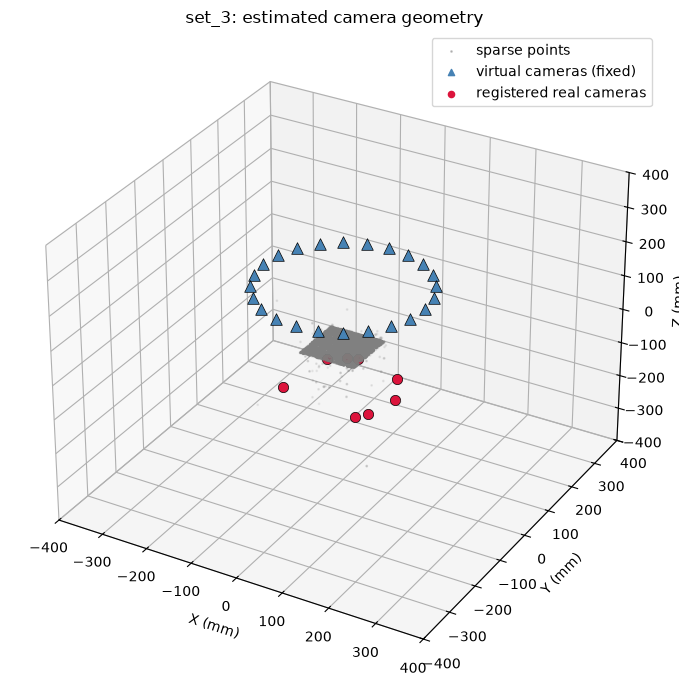

In [30]:
points_xyz = np.array([p.xyz for p in recon.points3D.values()])

# Exhaustive real<->real matching also triangulates points on the artefact/background, not just
# the plate - a handful of those can be wildly wrong (e.g. a spurious match on something far away
# like a window). Clip to a sensible radius around the plate/cameras so a few outliers don't
# blow out the axis scale.
plot_radius_mm = max(400.0, VIRTUAL_DISTANCE_MM * 1.5)
dist_from_origin = np.linalg.norm(points_xyz, axis=1)
points_plot = points_xyz[dist_from_origin < plot_radius_mm]
print(f"plotting {len(points_plot)} / {len(points_xyz)} points within {plot_radius_mm:.0f}mm of the plate")

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(points_plot[:, 0], points_plot[:, 1], points_plot[:, 2], s=1, c="gray", alpha=0.4, label="sparse points")

for img in recon.images.values():
    if not img.has_pose:
        continue
    center = img.projection_center()
    is_virtual = img.name in set(virtual_rel_names)
    ax.scatter(*center, s=70 if is_virtual else 55,
               color="steelblue" if is_virtual else "crimson",
               marker="^" if is_virtual else "o",
               edgecolors="black", linewidths=0.5, depthshade=False)

ax.scatter([], [], color="steelblue", marker="^", label="virtual cameras (fixed)")
ax.scatter([], [], color="crimson", marker="o", label="registered real cameras")
ax.set_xlim(-plot_radius_mm, plot_radius_mm)
ax.set_ylim(-plot_radius_mm, plot_radius_mm)
ax.set_zlim(-plot_radius_mm, plot_radius_mm)
ax.set_xlabel("X (mm)"); ax.set_ylabel("Y (mm)"); ax.set_zlabel("Z (mm)")
ax.set_title(f"{SET_NAME}: estimated camera geometry")
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 - Remove the virtual photographs

The final stage: strip the virtual images out, leaving only the real, calibrated cameras and the
points they observe - ready for dense point-cloud reconstruction.

In [37]:
final_recon = colmap_calibration.strip_virtual_images(recon, set(virtual_rel_names))

FINAL_DIR.mkdir(parents=True, exist_ok=True)
final_recon.write(FINAL_DIR)
final_recon.export_PLY(str(FINAL_DIR / "sparse_cloud.ply"))

print(final_recon.summary())
print(f"final reconstruction written to {FINAL_DIR}")
print("registered real cameras:", sorted(img.name for img in final_recon.images.values() if img.has_pose))

Reconstruction:
	num_rigs = 1
	num_cameras = 1
	num_frames = 32
	num_reg_frames = 8
	num_images = 32
	num_points3D = 3607
	num_observations = 10159
	mean_track_length = 2.81647
	mean_observations_per_image = 1269.88
	mean_reprojection_error = 0.595921
final reconstruction written to /home/gnoceras/ScanningTable/outputs/set_1/final
registered real cameras: ['set_1/01_stop_04_20260714_172251.jpg', 'set_1/01_stop_06_20260714_172302.jpg', 'set_1/01_stop_07_20260714_172308.jpg', 'set_1/01_stop_13_20260714_172343.jpg', 'set_1/01_stop_19_20260714_172418.jpg', 'set_1/01_stop_21_20260714_172430.jpg', 'set_1/01_stop_23_20260714_172442.jpg', 'set_1/01_stop_34_20260714_172548.jpg']


## Reprojection error

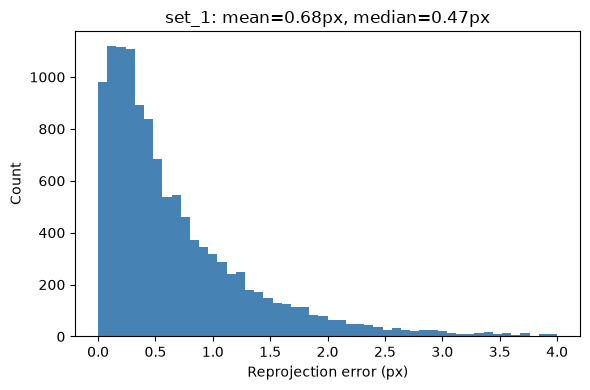

In [18]:
errors = []
for img in final_recon.images.values():
    if not img.has_pose:
        continue
    cam = final_recon.camera(img.camera_id)
    for p2d in img.points2D:
        if not p2d.has_point3D():
            continue
        pt3d = final_recon.point3D(p2d.point3D_id)
        projected = img.project_point(pt3d.xyz)
        if projected is not None:
            errors.append(np.linalg.norm(np.array(projected) - np.array(p2d.xy)))

errors = np.array(errors)
plt.figure(figsize=(6, 4))
plt.hist(errors, bins=50, color="steelblue")
plt.xlabel("Reprojection error (px)"); plt.ylabel("Count")
plt.title(f"{SET_NAME}: mean={errors.mean():.2f}px, median={np.median(errors):.2f}px")
plt.tight_layout()
plt.show()